## Task1

In [26]:
import sympy as sp
import numpy as np
import time as t
!pip install plotnine
from plotnine import *
import pandas as pd

Defaulting to user installation because normal site-packages is not writeable
    pytz (>=2011n)
         ~~~~~~~^


In [27]:

x1, x2 = sp.symbols('x1 x2')
func = 100 * (x2 - x1**2)**2 + (1 - x1)**2
df_dx1 = sp.diff(func, x1)
df_dx2 = sp.diff(func, x2)
objective_func = sp.lambdify((x1, x2), func, 'numpy')
gradient_func = sp.lambdify((x1, x2), [df_dx1, df_dx2], 'numpy')

def calculate_objective(x:np.array)->float:
    return objective_func(x[0], x[1])

def calculate_gradient(x: np.array):
    return np.array(gradient_func(x[0], x[1]))

def gradient_descent(step:float, error =1e-4, max_iter = 1000):
    x = np.array([-2, 2])
    objective_values = []
    time_start = t.time()

    for i in range(max_iter):
        grad = calculate_gradient(x)
        next_x = x - step * grad
        objective_values.append(calculate_objective(next_x))
        if  np.linalg.norm(grad) < error :
            break
        x = next_x

    finish_time = t.time() - time_start
    return objective_values, finish_time




In [28]:
steps = [0.0001, 0.00001]
all_objective_values = pd.DataFrame(columns=['objective_value', 'iteration', 'step'])
for step in steps:
    objective_values, time = gradient_descent(step)
    print(f'for step {step} it took {time} and itterations: {len(objective_values)} for this final result {objective_values[-1]}')
    temp_df = pd.DataFrame({
        'objective_value': objective_values,
        'iteration': np.arange(1, len(objective_values) + 1),
        'step': str(step)
    })

    all_objective_values = pd.concat([all_objective_values, temp_df], ignore_index=True)



for step 0.0001 it took 0.008617401123046875 and itterations: 1000 for this final result 5.823394948751783
for step 1e-05 it took 0.0083770751953125 and itterations: 1000 for this final result 6.059067199326528


/tmp/ipykernel_15696/2998278356.py:12: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.


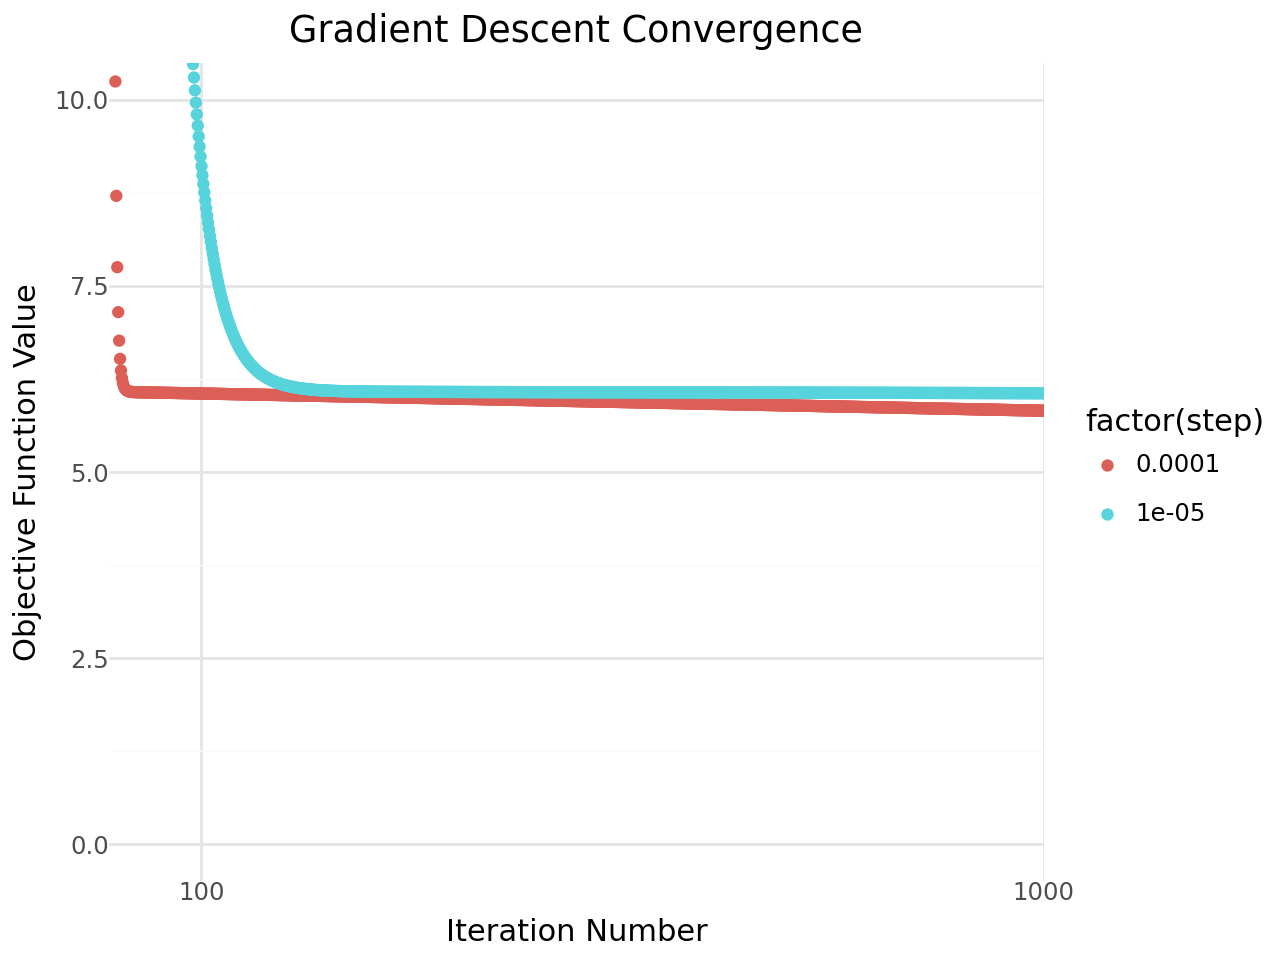

In [30]:
fig = (ggplot(all_objective_values, aes(x="iteration", y="objective_value", color="factor(step)")) +
       geom_point() +
       labs(title="Gradient Descent Convergence", x="Iteration Number", y="Objective Function Value") +
        coord_cartesian(xlim=(100, 1000), ylim=(0, 10)) +
       theme_minimal())
fig

## Task2

In [31]:
df = pd.read_csv("Concrete_Data.csv")
A = df.iloc[:, :3].to_numpy()
A = (A - np.mean(A, axis=0)) / np.std(A, axis=0)
b = df.iloc[:, -1].to_numpy().reshape(-1, 1)
b = (b - np.mean(b, axis=0)) / np.std(b, axis=0)
m = b.shape[0]
n = A.shape[1]

In [32]:
def lse_func(A:np.array, b:np.array, x:np.array) -> np.array:
    return (1 / (2 * m)) * np.linalg.norm(A @ x - b)**2

def calculate_gradient_lse(A:np.array, b:np.array, x:np.array):
    return A.T @ (A@ x -b)/m

def gradient_descent_lse(step:float, error =1e-4, max_iter = 50):
    x = np.zeros((n, 1))
    objective_values = []
    time_start = t.time()
    for i in range(max_iter):
        grad = calculate_gradient_lse(A, b, x)
        next_x = x - step * grad
        objective_values.append(lse_func(A, b, next_x))
        if  np.linalg.norm(grad) < error :
            break
        x = next_x

    finish_time = t.time() - time_start
    return objective_values, finish_time


In [37]:
L_1 = np.linalg.norm(A, 2)/m
L_2 = (1 / A.shape[0]) * (np.linalg.norm(A.T @ A, 2) * 20 + np.linalg.norm(A.T @ b, 2))

steps_lse = [0.001, 0.0001, 1/(L_1), 1/(L_2)]
all_objective_values_lse = pd.DataFrame(columns=['objective_value', 'iteration', 'step'])
i = 0
for st in steps_lse:
    objective_values, _ = gradient_descent_lse(st, max_iter=20)
    print(f"Step {st}: {len(objective_values)} iterations")

    temp_df = pd.DataFrame({
        'objective_value': objective_values,
        'iteration': np.arange(1, len(objective_values) + 1),
        'step': f'{st}'
    })
    if i!=2:
        all_objective_values_lse = pd.concat([all_objective_values_lse, temp_df], ignore_index=True)
    i+=1

Step 0.001: 20 iterations
Step 0.0001: 20 iterations
Step 27.085816523747884: 20 iterations
Step 0.034958179408063214: 20 iterations


/tmp/ipykernel_15696/3056538574.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.


In [38]:
all_objective_values_lse

,objective_value,iteration,step
0,0.499723,1,0.001
1,0.499446,2,0.001
2,0.499171,3,0.001
3,0.498895,4,0.001
4,0.498621,5,0.001
5,0.498346,6,0.001
6,0.498073,7,0.001
7,0.497800,8,0.001
8,0.497527,9,0.001
9,0.497255,10,0.001


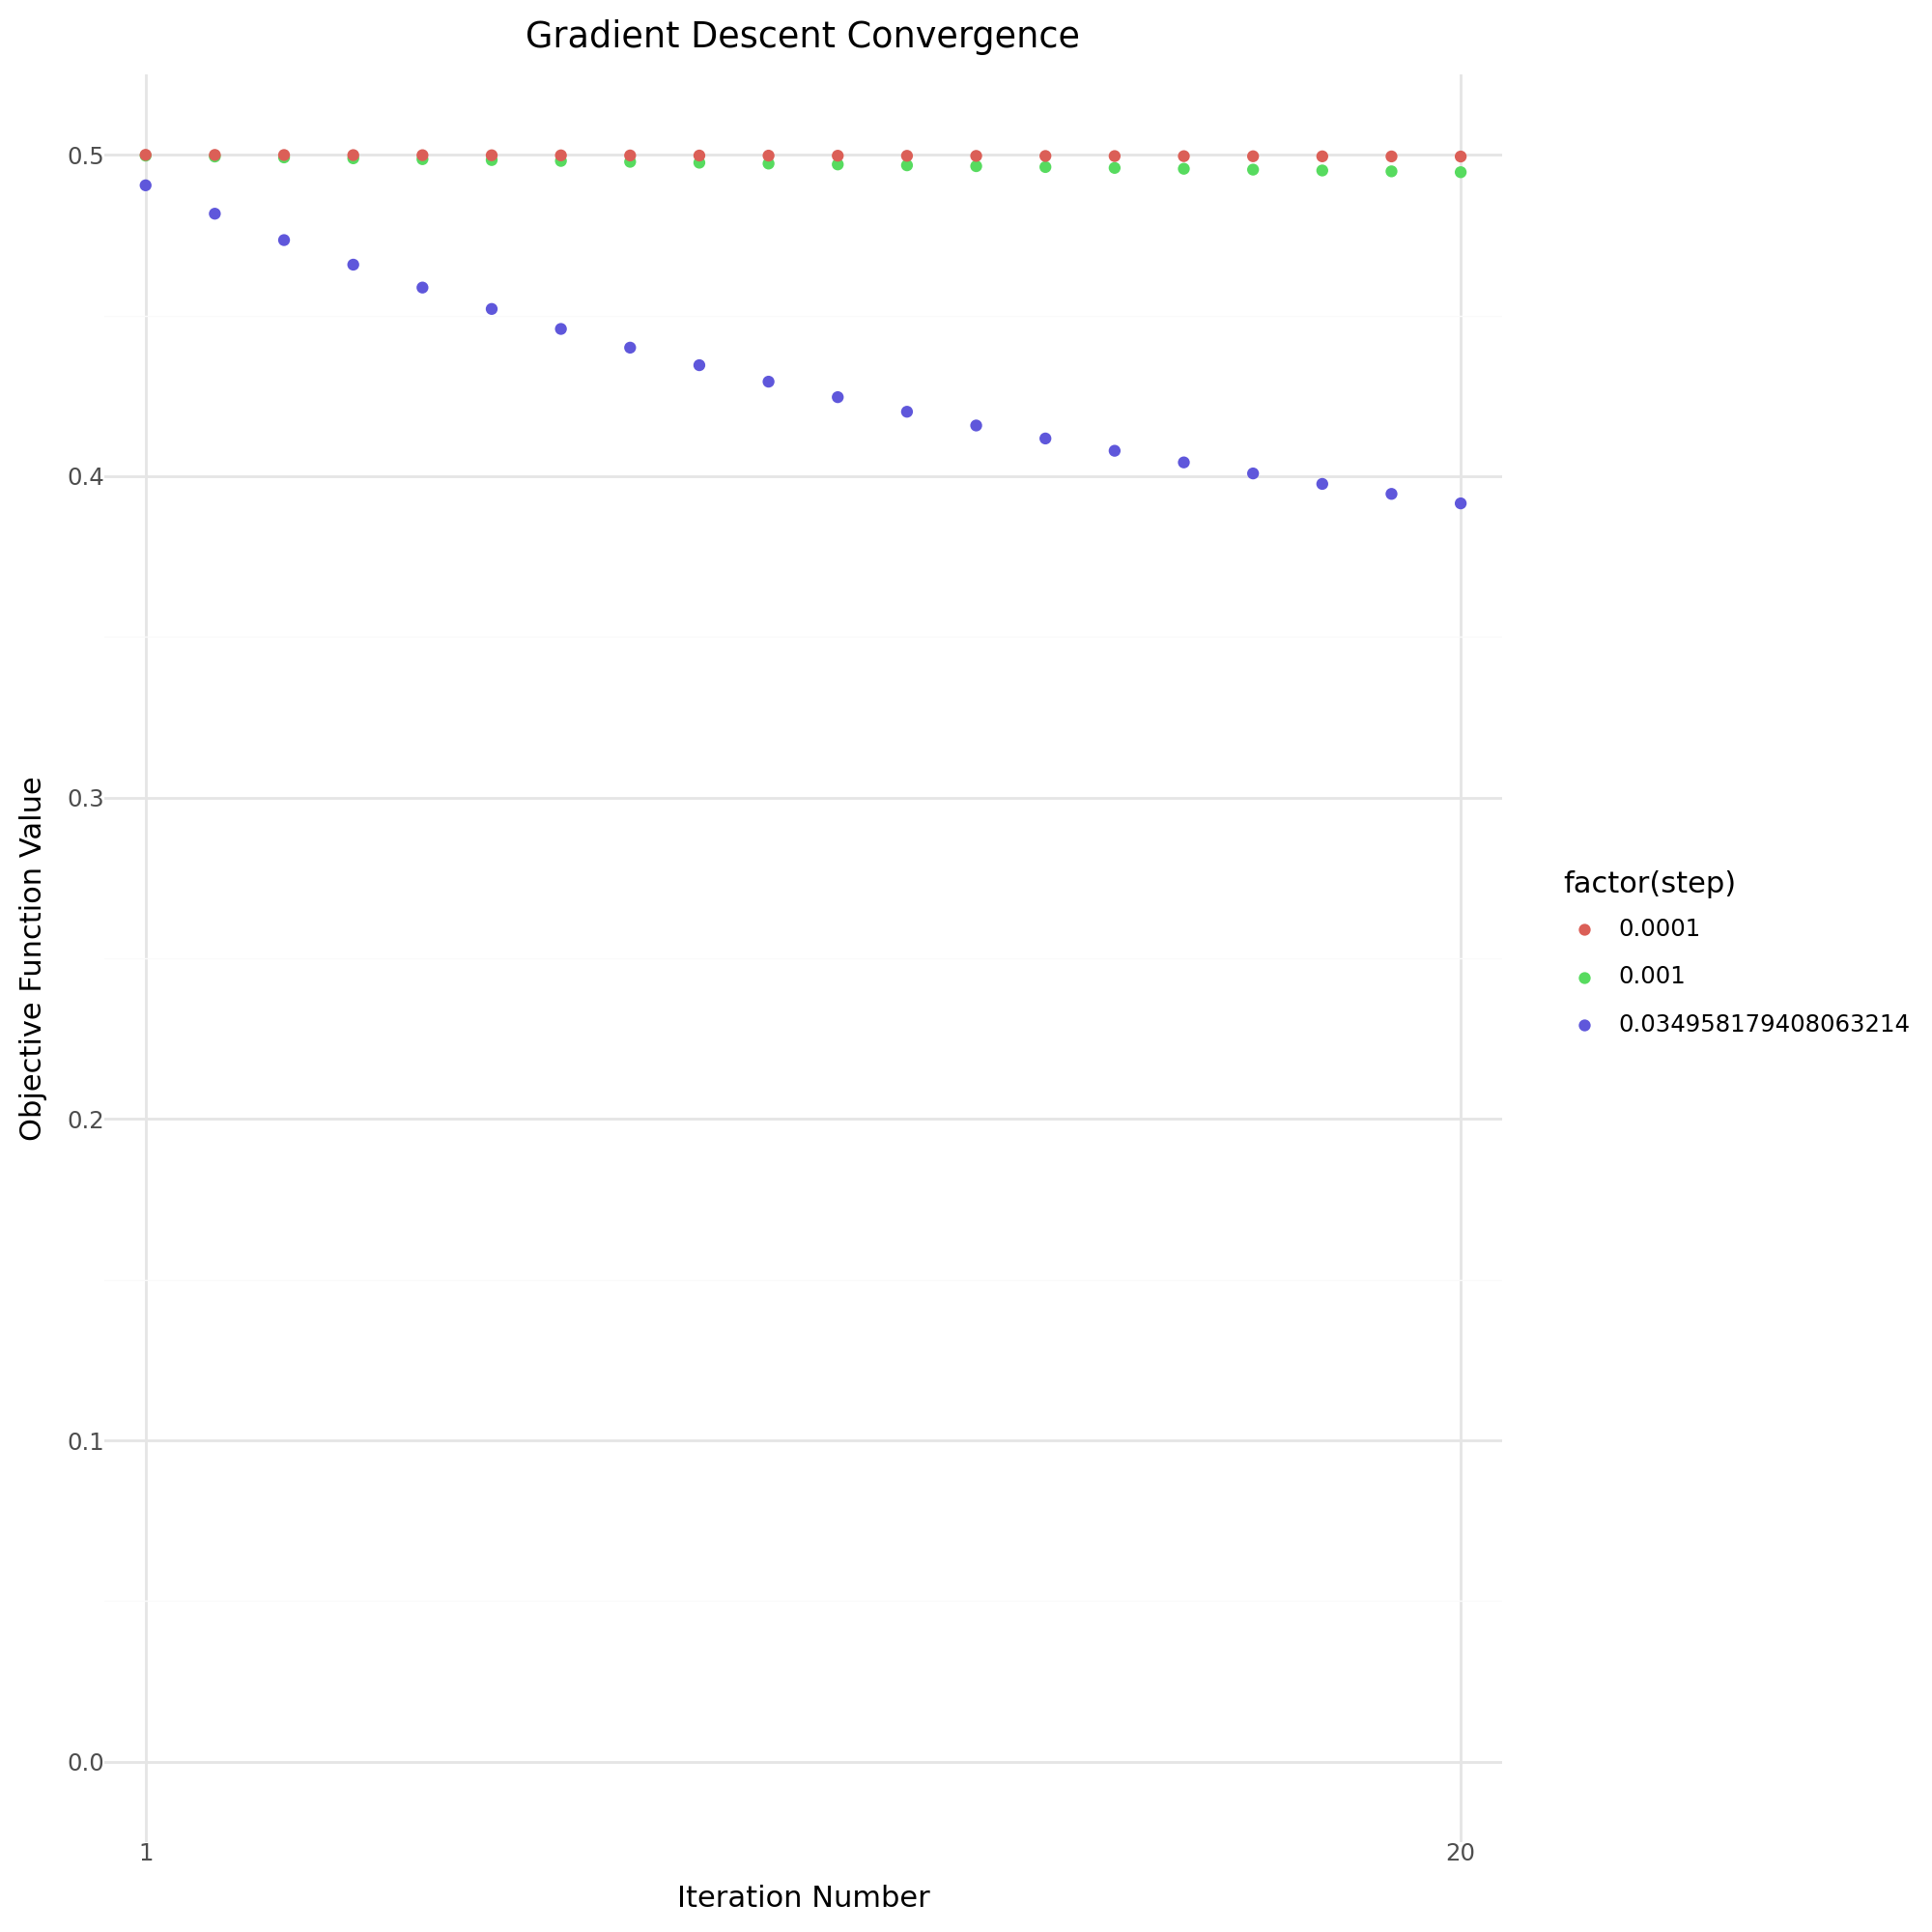

In [46]:
fig_1 = (ggplot(all_objective_values_lse, aes(x="iteration", y="objective_value", color="factor(step)")) +
       geom_point() +
       labs(title="Gradient Descent Convergence", x="Iteration Number", y="Objective Function Value") +
        coord_cartesian(xlim=(1, 20), ylim=(0, 0.5)) +
       theme_minimal()+
         theme(figure_size = (10, 10)))
fig_1

## Task 3

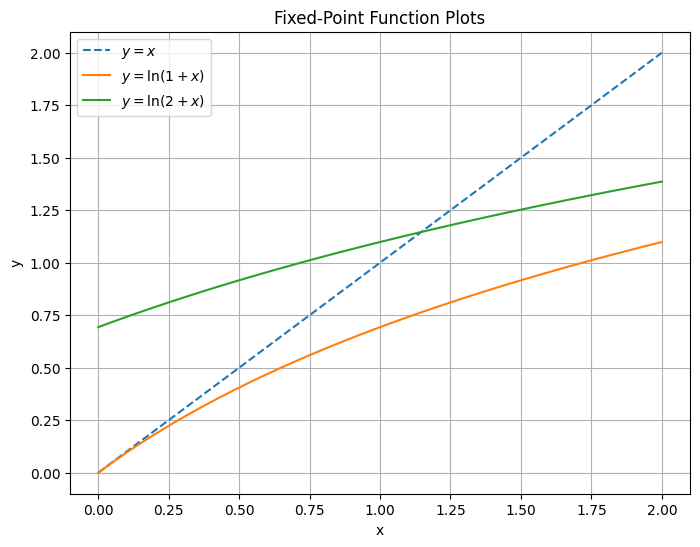

In [47]:
import matplotlib.pyplot as plt
x = np.linspace(0, 2, 100)
y1 = x
y2 = np.log(1 + x)
y3 = np.log(2 + x)

plt.figure(figsize=(8, 6))
plt.plot(x, y1, label=r'$y = x$', linestyle='--')
plt.plot(x, y2, label=r'$y = \ln(1 + x)$')
plt.plot(x, y3, label=r'$y = \ln(2 + x)$')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Fixed-Point Function Plots')
plt.legend()
plt.grid(True)

plt.show()


In [73]:
import numpy as np
from scipy.optimize import minimize_scalar
#find derivatives

def gradient_descent_ln(step:float, func, gradient, error =1e-4, max_iter =100):
    x = 1
    objective_values = []
    time_start = t.time()
    for i in range(max_iter):
        grad = gradient(x)
        next_x = x - step * grad
        objective_values.append(func(next_x))
        if  np.linalg.norm(grad) < error :
            break
        x = next_x

    finish_time = t.time() - time_start
    return objective_values, finish_time



In [74]:
def minus_g1(x):
    return -0.5 * (x - np.log(1 + x))**2

def minus_g2(x):
    return -0.5 * (x - np.log(2 + x))**2

def g1(x):
    return 0.5 * (x - np.log(1 + x))**2

def grad_g1(x):
    return (x - np.log(1 + x)) * (1 - (1 / (1 + x)))

def g2(x):
    return 0.5 * (x - np.log(2 + x))**2

def grad_g2(x):
    return (x - np.log(2 + x)) * (1 - (1 / (2 + x)))

def max_value(func):
    result = minimize_scalar(func, bounds=(0, 2), method='bounded')
    max_value = -result.fun
    return result.x

l_1 = max_value(minus_g1)
l_2 = max_value(minus_g2)

In [75]:
values_1, time_1 = gradient_descent_ln(l_1,g1, grad_g1 )
values_2, time_2 = gradient_descent_ln(l_2,g2, grad_g2 )

[0.004862174300449633,
 0.004862156862778966,
 0.004862139425169301,
 0.004862121987620641,
 0.004862104550132963,
 0.00486208711270629,
 0.004862069675340597,
 0.00486205223803593,
 0.0048620348007922445,
 0.004862017363609541,
 0.004861999926487839,
 0.004861982489427141,
 0.004861965052427445,
 0.004861947615488708,
 0.004861930178610995,
 0.004861912741794263,
 0.004861895305038532,
 0.004861877868343782,
 0.004861860431710056,
 0.004861842995137287,
 0.004861825558625541,
 0.004861808122174774,
 0.004861790685784987,
 0.004861773249456201,
 0.004861755813188416,
 0.004861738376981631,
 0.004861720940835802,
 0.004861703504750975,
 0.0048616860687271685,
 0.0048616686327643405,
 0.0048616511968624905,
 0.00486163376102164,
 0.004861616325241768,
 0.0048615988895228945,
 0.0048615814538650205,
 0.004861564018268124,
 0.004861546582732225,
 0.004861529147257303,
 0.004861511711843381,
 0.0048614942764904565,
 0.0048614768411985075,
 0.004861459405967558,
 0.004861441970797605,
 0.004

Time for first func: 0.0008020401000976562
Time for first func: 0.0009810924530029297


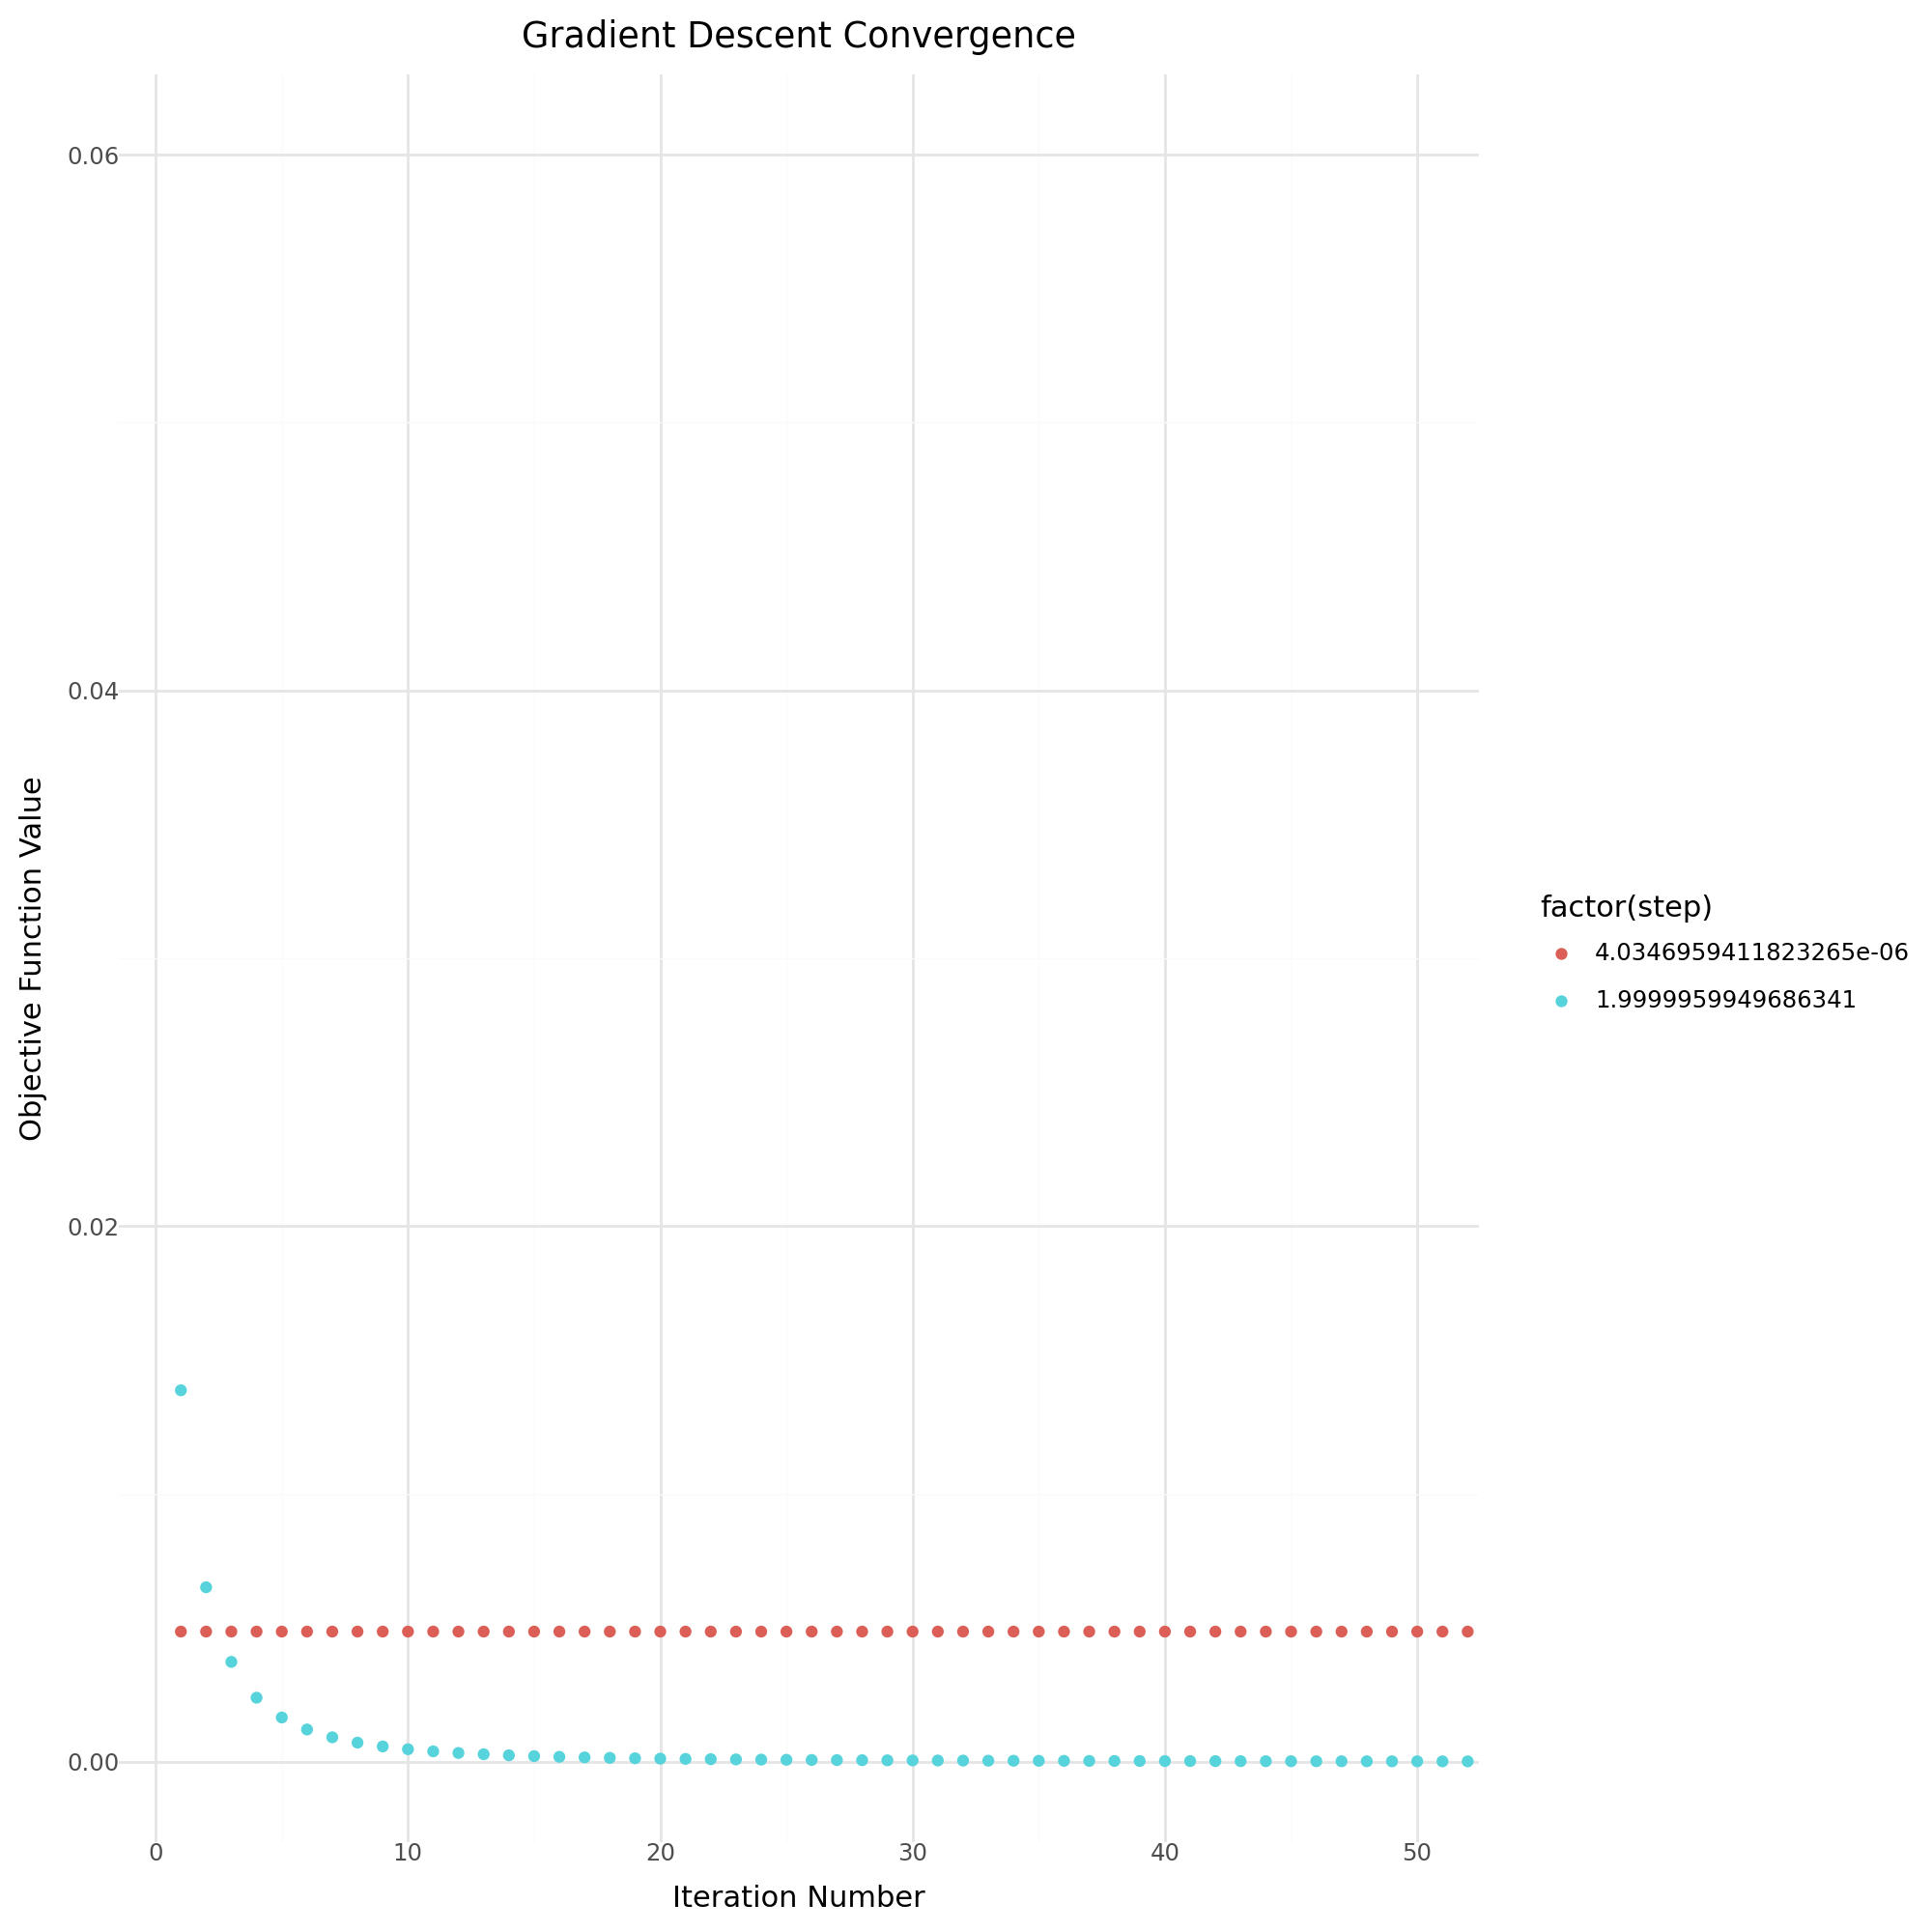

In [84]:

df_1 = pd.DataFrame({
    'iteration': np.arange(1, len(values_1) + 1),
    'objective_value': values_1,
    'step': l_1
})
print('Time for first func:', time_1)
df_2 = pd.DataFrame({
    'iteration': np.arange(1, len(values_1) + 1),
    'objective_value': values_2,
    'step': l_2
})
print('Time for first func:', time_2)
all_objective_values_ln = pd.concat([df_1, df_2], ignore_index=True)

# Plot the results
fig_2 = (ggplot(all_objective_values_ln, aes(x="iteration", y="objective_value", color="factor(step)")) +
         geom_point() +
         labs(title="Gradient Descent Convergence", x="Iteration Number", y="Objective Function Value") +
         coord_cartesian(xlim=(1, 50), ylim=(0, 0.06)) +
         theme_minimal() +
         theme(figure_size=(10, 10)))
fig_2